# SM120 Dense GEMM Tensor Walkthrough

This SM120 kernel computes `C = A x B` for a single CTA tile with:

- `A : (M, K, L)`
- `B : (N, K, L)`
- `C : (M, N, L)`

For the default example, that means one `32x32x32` GEMM tile with batched dimension `L = 1`.

Unlike the SM100 notebook, this kernel does **not** use TMEM or `tcgen05.ld`. The accumulator lives directly in registers, so the dataflow is simpler:

```text
GMEM -- TMA load --> SMEM -- ldmatrix/copy --> RMEM -- warp MMA --> accumulator registers -- epilogue copy --> SMEM -- TMA store --> GMEM
```

| Stage | Instruction | Layout |
| --- | --- | --- |
| GMEM | - | Logical A/B/C tensors with majors selected by `a_major`, `b_major`, `c_major` |
| GMEM -> SMEM | `cp.async.bulk.tensor` (TMA load) | Staged swizzled `32x32` tiles, e.g. `sA = ((32,1),(8,4),(1,20)):((1,0),(32,256),(0,1024))` |
| SMEM -> RMEM | `ldmatrix`-style warp copy (`cute.nvgpu.warp.LdMatrix8x8x16bOp`) | Per-thread MMA source partitions `tCsA/tCsB` loaded into register fragments `tCrA/tCrB` |
| RMEM | `cute.gemm(...)` with warp MMA atom | Warp MMA atom `16x8x16`, tiled to `32x32x16` per K block with `atom_layout = (2,2,1)` |
| RMEM accumulator | - | Float32 accumulator fragment `accumulators`, shaped from `tCgC.shape[:3]` |
| RMEM -> SMEM | `copy` / `stmatrix`-style epilogue path | Results converted and staged through `sC`, an epilogue SMEM tensor with 8 stages |
| SMEM -> GMEM | `cp.async.bulk.tensor` (TMA store) | TMA store from `sC` back to the CTA-local `gC_mnl` tile and then logical `C` |

Two details are worth keeping in mind:

- one warp-MMA step covers `32x32x16`, not the full `32x32x32` CTA tile
- the full CTA tile is completed by iterating over **two** K-blocks of depth 16

This notebook mirrors the style of the SM100 layout walkthrough, but it is built around the kernel in `/home/user/cuda/sm120/dense_gemm.py`.

The goal is to show:

- which tensors live in GMEM, SMEM, and RMEM
- how the printed CuTe layouts relate to the `32x32x32` example run
- how data moves through the kernel: `GMEM -> SMEM -> registers -> MMA accumulators -> SMEM -> GMEM`

This notebook uses the default example configuration from `dense_gemm.py`:

- `mnkl = (32, 32, 32, 1)`
- `tile_shape_mnk = (32, 32, 32)`
- `A/B/C = Float16`, `Acc = Float32`
- `A major = k`, `B major = k`, `C major = n`


In [25]:
from tensor_layouts import Layout, Swizzle
from tensor_layouts.viz import draw_layout, draw_swizzle
from IPython.display import Markdown, display


def show_layout(title, layout, note=None, colorize=True):
    display(Markdown(f"### {title}"))
    print(layout)
    if note:
        display(Markdown(note))
    draw_layout(layout, title=title, colorize=colorize)


def show_swizzle(title, layout, swizzle, note=None, colorize=True):
    display(Markdown(f"### {title}"))
    print(f"outer  = {layout}")
    print(f"inner  = {swizzle}")
    print("shown  = inner(outer(coord))")
    if note:
        display(Markdown(note))
    try:
        draw_swizzle(layout, swizzle, title=title, colorize=colorize)
    except TypeError:
        draw_swizzle(layout, swizzle, colorize=colorize)


def show_text(title, body):
    display(Markdown(f"### {title}\n\n{body}"))


## 1. Tensor inventory from `sm120/dense_gemm.py`

The kernel prints these tensor/layout names during the reference-check path.

The important ones are:

- `mA_mkl`, `mB_nkl`, `mC_mnl`: logical global-memory tensors
- `gA_mkl`, `gB_nkl`, `gC_mnl`: CTA-local GMEM tiles
- `sA`, `sB`, `sC`: staged SMEM tensors
- `tAgA`, `tBgB`: TMA views of global tiles
- `tAsA`, `tBsB`: TMA views of shared-memory destination tiles
- `tCsA`, `tCsB`: per-thread SMEM partitions for the MMA path
- `tCrA`, `tCrB`: register fragments loaded from SMEM for MMA
- `tCgC`: per-thread mapping of output coordinates
- `accumulators`: the actual RMEM tensor that holds MMA results

One subtle point: there is no explicit `tCrC` variable in this kernel. The accumulator fragment is created directly as:

```python
tCgC = thr_mma.partition_C(gC_mnl)
acc_shape = tCgC.shape[:3]
accumulators = cute.make_rmem_tensor(acc_shape, self.acc_dtype)
```

So:

- `tCgC` tells each thread where its results belong in `C`
- `accumulators` holds those results in registers


In [26]:
tensor_summary = [
    ("mA_mkl", "GMEM", "logical A tensor, shape (M, K, L)"),
    ("mB_nkl", "GMEM", "logical B tensor, shape (N, K, L)"),
    ("mC_mnl", "GMEM", "logical C tensor, shape (M, N, L)"),
    ("gA_mkl", "GMEM tile", "CTA-local tile of A used by TMA load"),
    ("gB_nkl", "GMEM tile", "CTA-local tile of B used by TMA load"),
    ("gC_mnl", "GMEM tile", "CTA-local tile of C used by the epilogue/TMA store"),
    ("sA", "SMEM", "staged shared-memory buffer for A"),
    ("sB", "SMEM", "staged shared-memory buffer for B"),
    ("sC", "SMEM", "staged shared-memory buffer for the epilogue"),
    ("tAgA / tBgB", "GMEM partition", "TMA source views"),
    ("tAsA / tBsB", "SMEM partition", "TMA destination views"),
    ("tCsA / tCsB", "SMEM partition", "per-thread MMA source partitions from SMEM"),
    ("tCrA / tCrB", "RMEM", "register fragments consumed by `cute.gemm(...)`"),
    ("tCgC", "logical output map", "per-thread coordinate map for C"),
    ("accumulators", "RMEM", "actual MMA accumulator fragment in registers"),
]

for name, space, role in tensor_summary:
    print(f"{name:14s} | {space:12s} | {role}")


mA_mkl         | GMEM         | logical A tensor, shape (M, K, L)
mB_nkl         | GMEM         | logical B tensor, shape (N, K, L)
mC_mnl         | GMEM         | logical C tensor, shape (M, N, L)
gA_mkl         | GMEM tile    | CTA-local tile of A used by TMA load
gB_nkl         | GMEM tile    | CTA-local tile of B used by TMA load
gC_mnl         | GMEM tile    | CTA-local tile of C used by the epilogue/TMA store
sA             | SMEM         | staged shared-memory buffer for A
sB             | SMEM         | staged shared-memory buffer for B
sC             | SMEM         | staged shared-memory buffer for the epilogue
tAgA / tBgB    | GMEM partition | TMA source views
tAsA / tBsB    | SMEM partition | TMA destination views
tCsA / tCsB    | SMEM partition | per-thread MMA source partitions from SMEM
tCrA / tCrB    | RMEM         | register fragments consumed by `cute.gemm(...)`
tCgC           | logical output map | per-thread coordinate map for C
accumulators   | RMEM         | actual

## 2. The shared-memory tensors `sA`, `sB`, `sC`

For the `32x32x32` run, the kernel prints:

```text
sA.layout = ((32,1),(8,4),(1,20)):((1,0),(32,256),(0,1024))
sB.layout = ((32,1),(8,4),(1,20)):((1,0),(32,256),(0,1024))
sC.layout = ((32,1),(8,4),(1,8)):((1,0),(32,256),(0,1024))
```

That printed `.layout` is the **outer/base coordinate layout**. It is not the whole physical SMEM mapping. The kernel builds each SMEM tensor from a CUTE `ComposedLayout` split into two parts:

```python
sA = storage.sA.get_tensor(
    a_smem_layout_staged.outer,
    swizzle=a_smem_layout_staged.inner,
)
```

So the full SMEM address path is:

```text
logical coordinate -> outer Layout offset -> inner swizzle -> physical SMEM address/bank
```

For this notebook's fixed default case, CUTLASS chooses `SmemLayoutAtomKind.K_SW64` for A, B, and C. Reading the CUTLASS source gives:

```text
K_SW64 -> Swizzle<2,4,3>
fp16 K_SW64 atom -> Layout((8, 32), stride=(32, 1)) before tiling to the full 32x32 stage
```

Why `K_SW64` here:

```text
major mode size = 32 fp16 elements
32 * 16 bits = 512 bits
512-bit K-major atom = K_SW64
```

Why CUTE splits it:

- `outer` keeps the normal tensor shape, strides, tiling, and pipeline-stage math easy to reason about.
- `inner` is the address permutation that changes which SMEM banks the outer offsets land in.
- Keeping them separate lets CUTE reuse the same logical tile layout with different swizzles.

The next cells are pure Python: first they print the fixed composed mapping, then they use `tensor_layouts` to draw both the outer layout and the swizzled physical mapping.


In [28]:
def swizzle_2_4_3(offset):
    """CUTE Swizzle<2,4,3> used by K_SW64 for this fp16 32-wide tile."""
    return offset ^ ((offset & (0b11 << 7)) >> 3)


def print_fixed_smem_layouts():
    """Print the fixed SMEM composed layouts for this notebook's default case.

    No CUTLASS import is needed. This is specialized to:
    - tile_shape_mnk = (32, 32, 32)
    - A/B/C dtype = fp16
    - a_major='k', b_major='k', c_major='n'

    CUTLASS chooses K_SW64 because the major mode is 32 fp16 elements:
        32 elements * 16 bits = 512 bits
    and K_SW64 is the 512-bit K-major swizzle atom.
    """
    outer_ab = "Layout(((32, 1), (8, 4), (1, 20)), ((1, 0), (32, 256), (0, 1024)))"
    outer_epi = "Layout(((32, 1), (8, 4), (1, 8)), ((1, 0), (32, 256), (0, 1024)))"
    inner = "Swizzle<2,4,3>  # offset ^ ((offset & (0b11 << 7)) >> 3)"

    for name, outer in (
        ("a_smem_layout_staged", outer_ab),
        ("b_smem_layout_staged", outer_ab),
        ("epi_smem_layout_staged", outer_epi),
    ):
        print(f"\n{name}")
        print("  selected atom kind: K_SW64")
        print(f"  composed: {inner} o {outer}")
        print(f"  outer:    {outer}")
        print(f"  inner:    {inner}")

    print("\nStage-0 coordinate examples for the physical SMEM element offset:")
    print("  m  k  outer_offset  physical_offset")
    for k in [0, 1, 7, 8, 15, 16, 23, 24, 31]:
        m = 0
        outer_offset = m + k * 32
        physical_offset = swizzle_2_4_3(outer_offset)
        print(f"  {m:1d} {k:2d} {outer_offset:12d} {physical_offset:15d}")


print_fixed_smem_layouts()



a_smem_layout_staged
  selected atom kind: K_SW64
  composed: Swizzle<2,4,3>  # offset ^ ((offset & (0b11 << 7)) >> 3) o Layout(((32, 1), (8, 4), (1, 20)), ((1, 0), (32, 256), (0, 1024)))
  outer:    Layout(((32, 1), (8, 4), (1, 20)), ((1, 0), (32, 256), (0, 1024)))
  inner:    Swizzle<2,4,3>  # offset ^ ((offset & (0b11 << 7)) >> 3)

b_smem_layout_staged
  selected atom kind: K_SW64
  composed: Swizzle<2,4,3>  # offset ^ ((offset & (0b11 << 7)) >> 3) o Layout(((32, 1), (8, 4), (1, 20)), ((1, 0), (32, 256), (0, 1024)))
  outer:    Layout(((32, 1), (8, 4), (1, 20)), ((1, 0), (32, 256), (0, 1024)))
  inner:    Swizzle<2,4,3>  # offset ^ ((offset & (0b11 << 7)) >> 3)

epi_smem_layout_staged
  selected atom kind: K_SW64
  composed: Swizzle<2,4,3>  # offset ^ ((offset & (0b11 << 7)) >> 3) o Layout(((32, 1), (8, 4), (1, 8)), ((1, 0), (32, 256), (0, 1024)))
  outer:    Layout(((32, 1), (8, 4), (1, 8)), ((1, 0), (32, 256), (0, 1024)))
  inner:    Swizzle<2,4,3>  # offset ^ ((offset & (0b11 <<

### sA stage 0: outer and swizzled physical layout


`outer`: `((32, 1), (8, 4)) : ((1, 0), (32, 256))`

`inner`: `Swizzle(2, 4, 3)`

The outer layout maps logical `(m, k)` coordinates to a base SMEM offset. For this one-stage `32x32` tile, `k = k0 + 8 * k1`, so:

```text
outer_offset = m + k0 * 32 + k1 * 256
             = m + k * 32
```

The physical SMEM mapping then applies `Swizzle(2, 4, 3)` to that offset.


### sA stage 0 outer layout only

((32, 1), (8, 4)) : ((1, 0), (32, 256))


This is the regular coordinate layout printed by `sA.layout`. It looks column-major because the swizzle has not been applied in this picture.

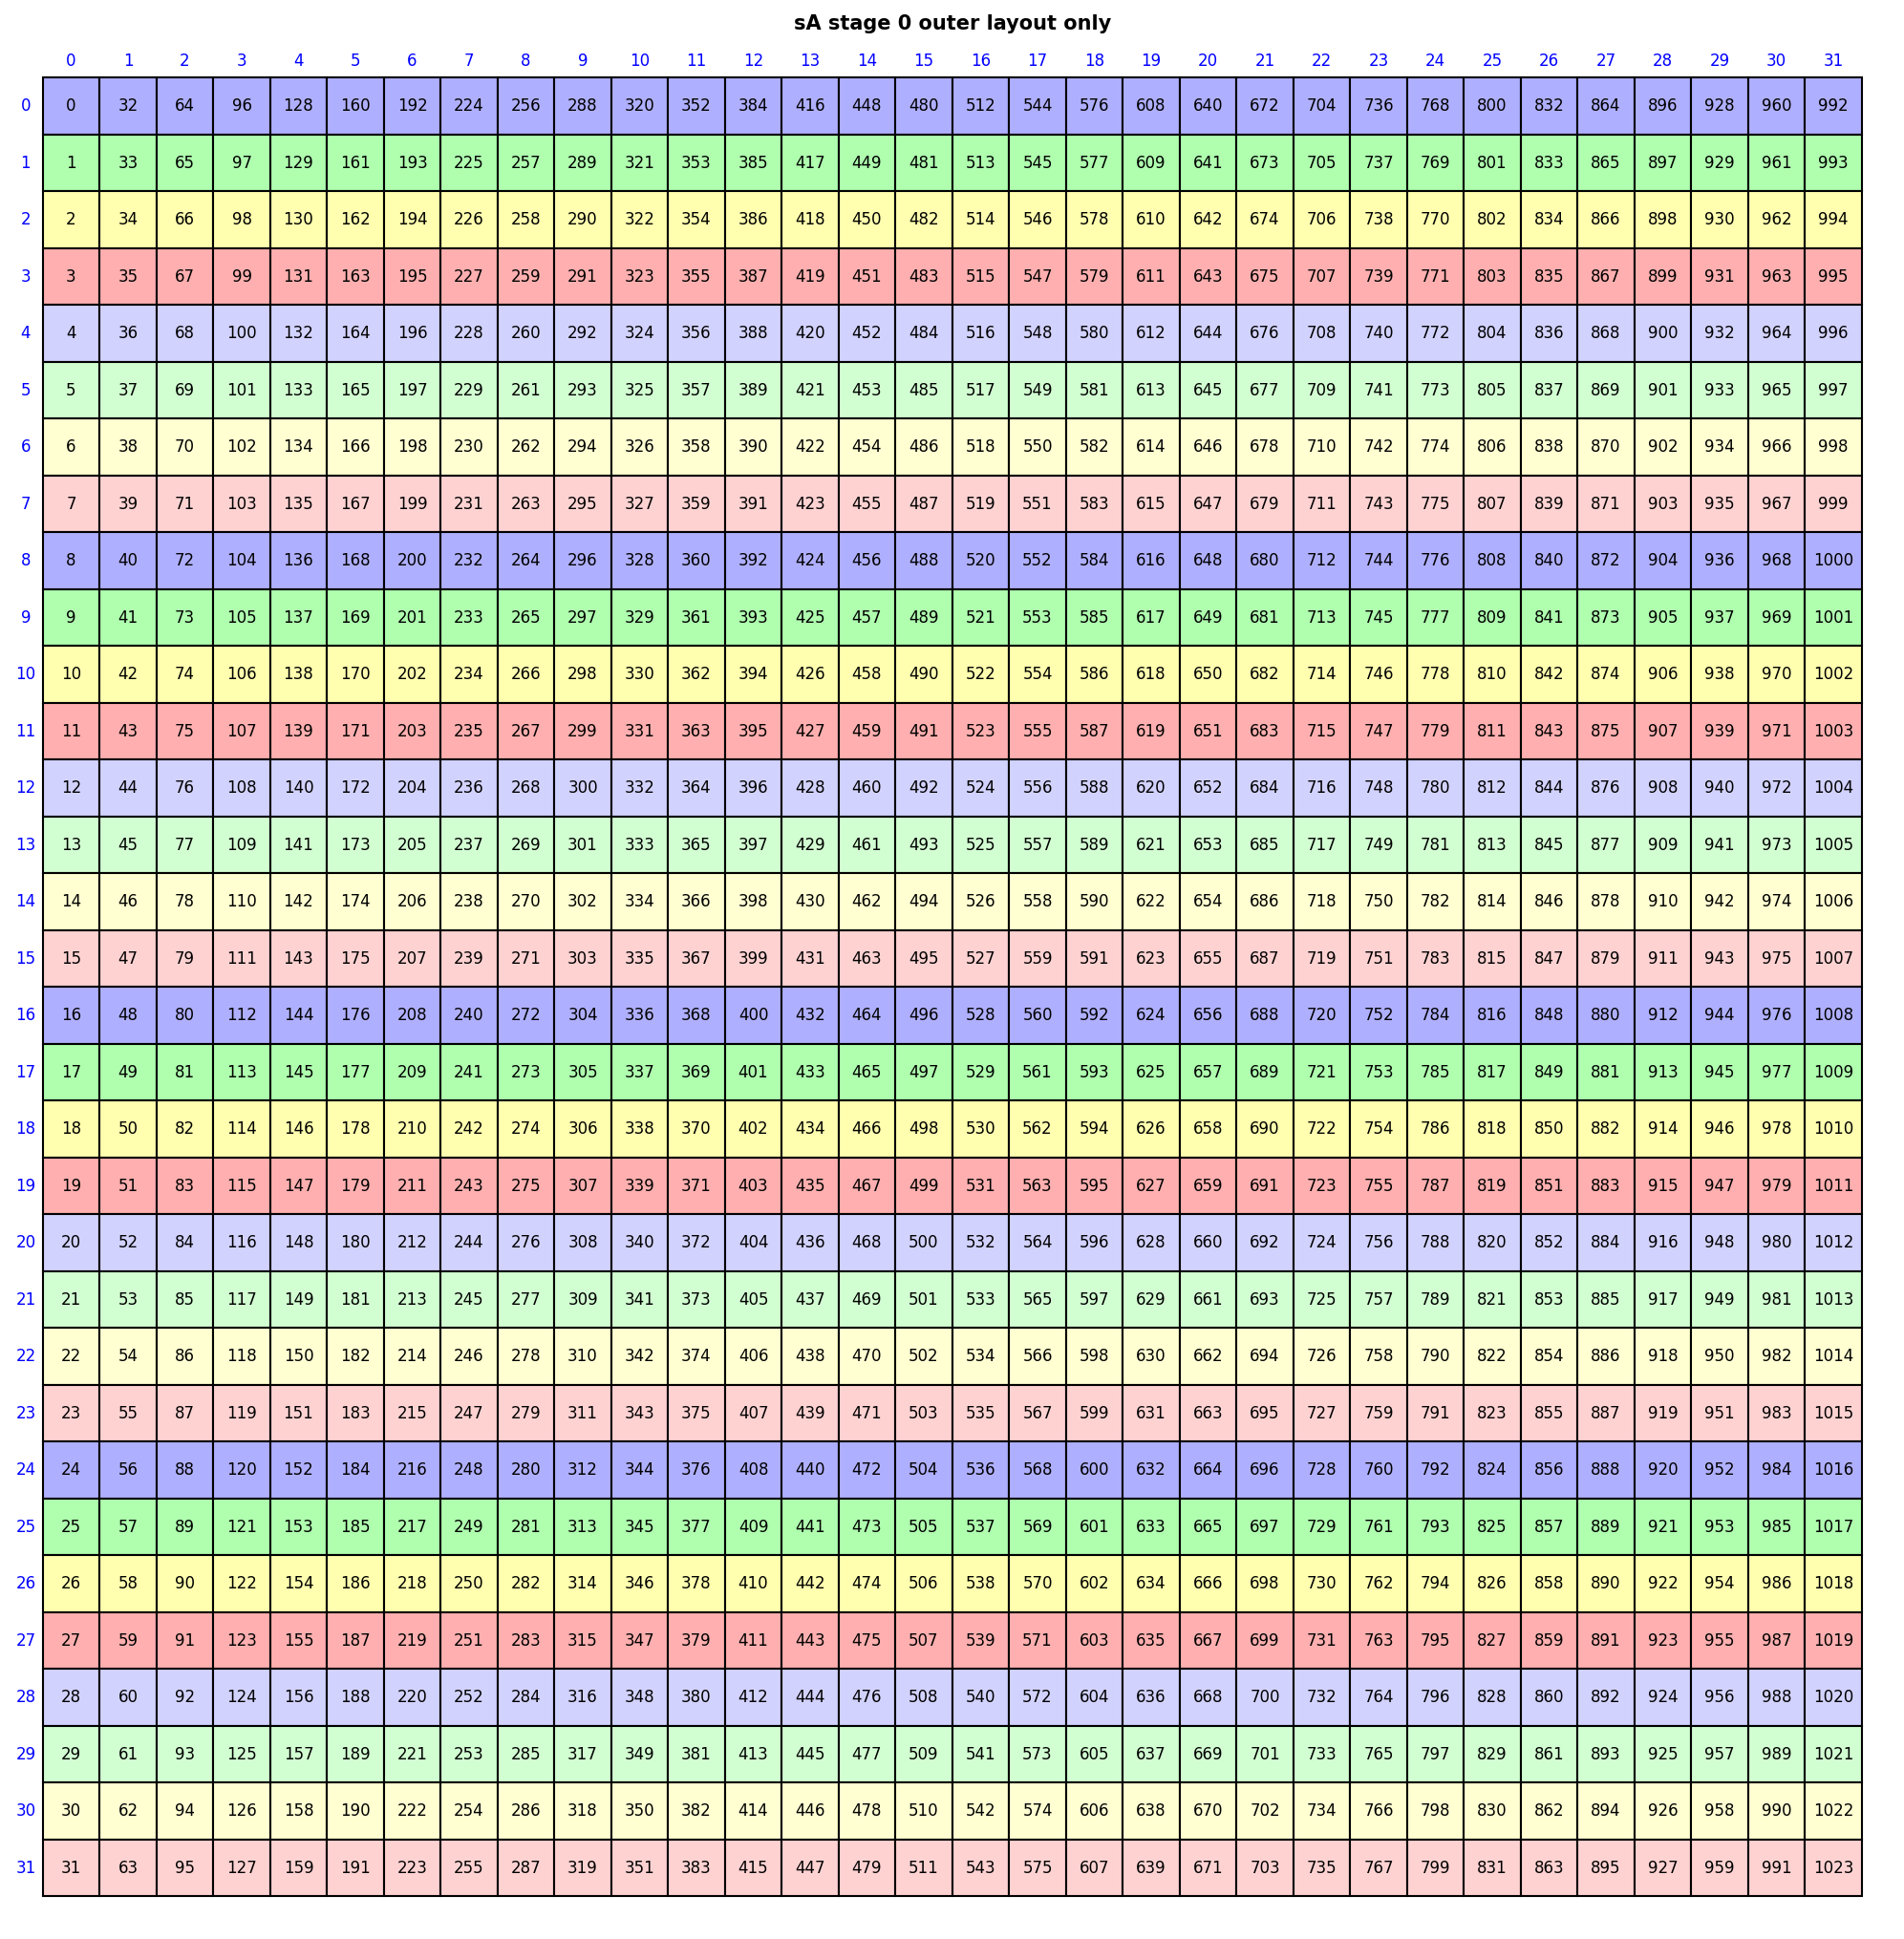

### sA stage 0 physical layout: outer + K_SW64 swizzle

outer  = ((32, 1), (8, 4)) : ((1, 0), (32, 256))
inner  = Swizzle(2, 4, 3)
shown  = inner(outer(coord))


This applies `Swizzle(2, 4, 3)` to the outer offsets. This is the picture to look at for the physical SMEM bank-conflict-avoidance mapping.

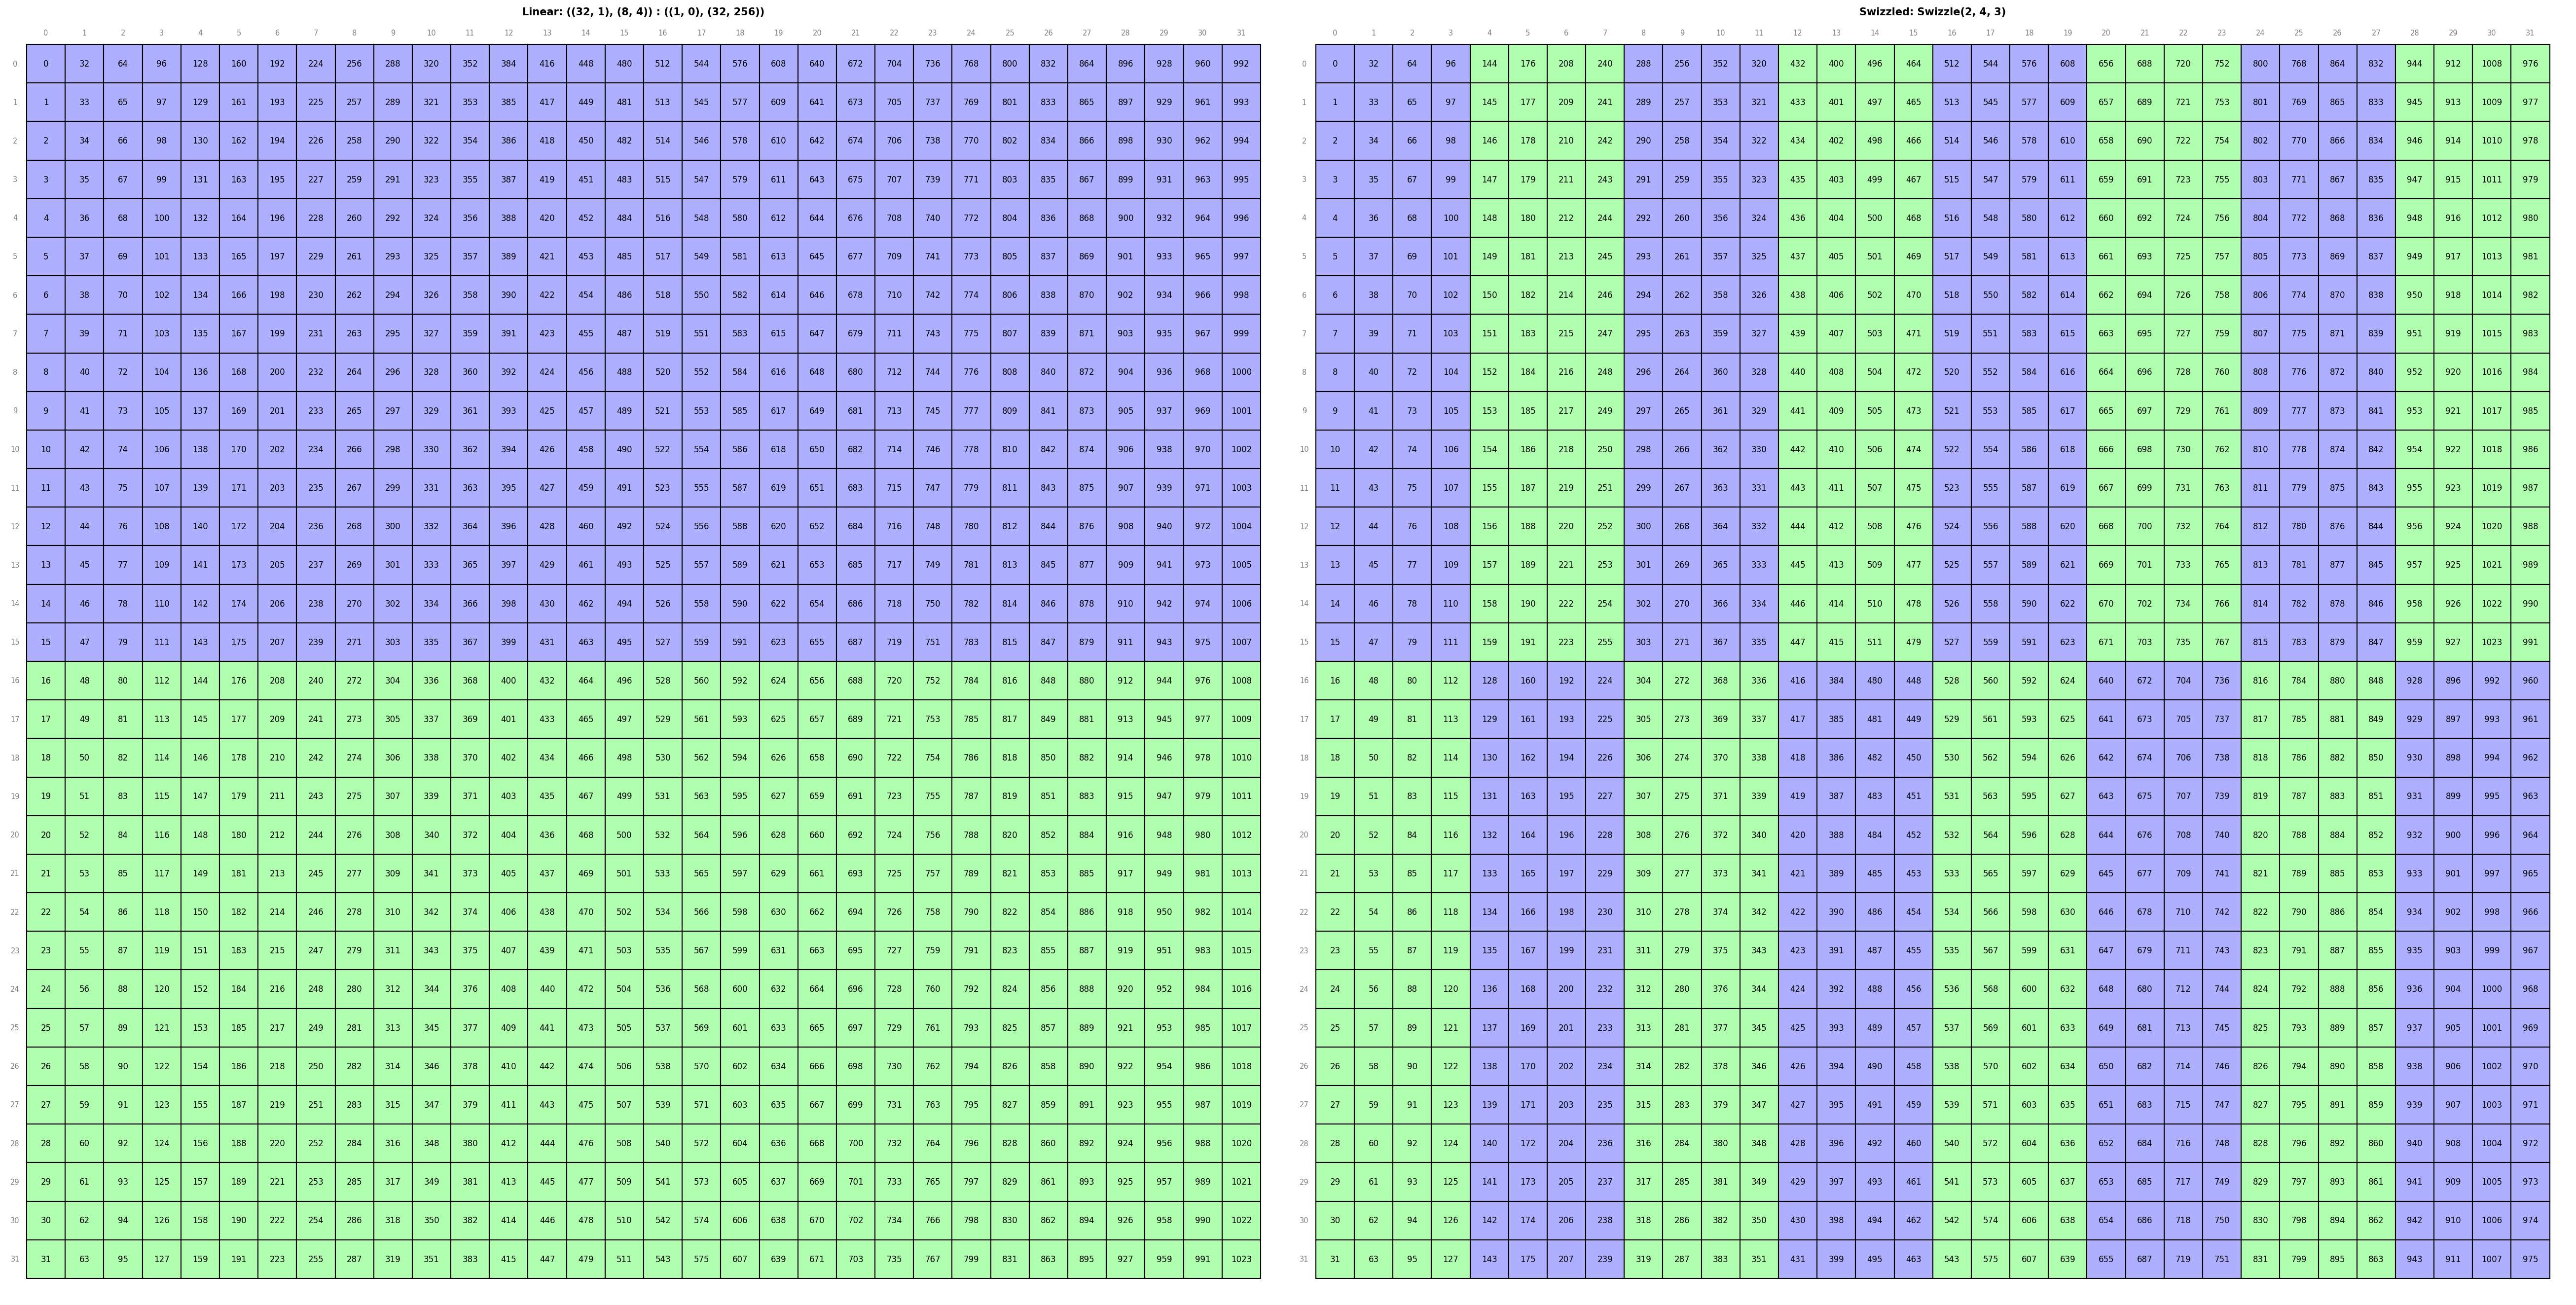

In [29]:
sA_stage0_outer = Layout(((32, 1), (8, 4)), ((1, 0), (32, 256)))
sB_stage0_outer = Layout(((32, 1), (8, 4)), ((1, 0), (32, 256)))
sC_stage0_outer = Layout(((32, 1), (8, 4)), ((1, 0), (32, 256)))
k_sw64_inner = Swizzle(2, 4, 3)

# These are only the outer layouts printed by `sA.layout`, `sB.layout`, and `sC.layout`.
# The physical SMEM mapping is the composed layout:
#     composed = inner swizzle applied to outer layout
sA_stage0 = sA_stage0_outer
sB_stage0 = sB_stage0_outer
sC_stage0 = sC_stage0_outer

show_text(
    "sA stage 0: outer and swizzled physical layout",
    f"""
`outer`: `{sA_stage0_outer}`

`inner`: `{k_sw64_inner}`

The outer layout maps logical `(m, k)` coordinates to a base SMEM offset. For this one-stage `32x32` tile, `k = k0 + 8 * k1`, so:

```text
outer_offset = m + k0 * 32 + k1 * 256
             = m + k * 32
```

The physical SMEM mapping then applies `Swizzle(2, 4, 3)` to that offset.
"""
)

show_layout(
    "sA stage 0 outer layout only",
    sA_stage0_outer,
    note="This is the regular coordinate layout printed by `sA.layout`. It looks column-major because the swizzle has not been applied in this picture."
)

show_swizzle(
    "sA stage 0 physical layout: outer + K_SW64 swizzle",
    sA_stage0_outer,
    k_sw64_inner,
    note="This applies `Swizzle(2, 4, 3)` to the outer offsets. This is the picture to look at for the physical SMEM bank-conflict-avoidance mapping."
)


In [ ]:
show_text(
    "sB and sC: outer and swizzled physical layouts",
    f"""
`sB outer`: `{sB_stage0_outer}`

`sC outer`: `{sC_stage0_outer}`

`inner`: `{k_sw64_inner}`

In this small example the stage-0 outer layouts for `sA`, `sB`, and `sC` are the same, and the fixed swizzle is also `K_SW64 = Swizzle(2, 4, 3)`. The stage count differs: A/B use 20 stages, C uses 8.
"""
)

show_layout(
    "sB stage 0 outer layout only",
    sB_stage0_outer,
    note="`sB` uses the same outer/base staged SMEM atom in this `32x32x32` example."
)

show_swizzle(
    "sB stage 0 physical layout: outer + K_SW64 swizzle",
    sB_stage0_outer,
    k_sw64_inner,
    note="This is `b_smem_layout_staged.inner` applied to `b_smem_layout_staged.outer`."
)

show_layout(
    "sC stage 0 outer layout only",
    sC_stage0_outer,
    note="The epilogue buffer `sC` uses the same stage-0 outer layout here, but it has `8` pipeline stages instead of `20`."
)

show_swizzle(
    "sC stage 0 physical layout: outer + K_SW64 swizzle",
    sC_stage0_outer,
    k_sw64_inner,
    note="This is `epi_smem_layout_staged.inner` applied to `epi_smem_layout_staged.outer`."
)


## 3. Per-thread MMA partitions from SMEM to registers

The kernel next partitions shared memory for the warp MMA path:

```python
tCsA = thr_mma.partition_A(sA)
tCsB = thr_mma.partition_B(sB)
tCrA = tiled_mma.make_fragment_A(tCsA[None, None, None, 0])
tCrB = tiled_mma.make_fragment_B(tCsB[None, None, None, 0])
```

For the example run, the printed layouts are:

```text
tCsA.layout = ((2,2,2),1,2,(1,20)):((32,8,256),0,512,(0,1024))
tCrA.layout = ((2,2,2),1,2):((1,2,4),0,8)
tCsB.layout = ((2,2),2,2,(1,20)):((32,256),16,512,(0,1024))
tCrB.layout = ((2,2),2,2):((1,2),4,8)
```

Again, for pictures it helps to ignore the stage dimension and just look at one stage.


### tCsA stage 0

((2, 2, 2), 1, 2) : ((32, 8, 256), 0, 512)


Thread-local view of A in SMEM. This is the partition that `ldmatrix`-style loads read from.

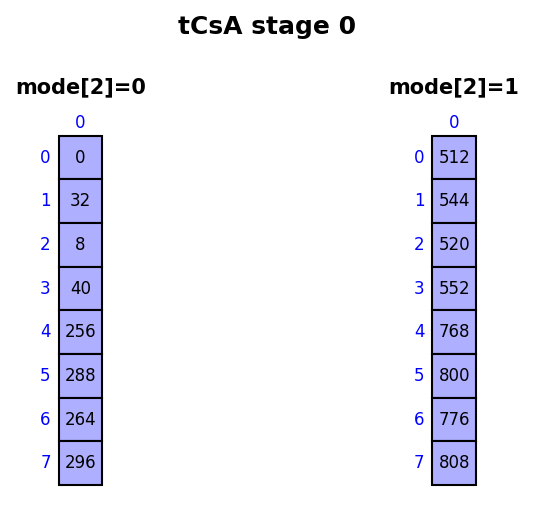

### tCrA

((2, 2, 2), 1, 2) : ((1, 2, 4), 0, 8)


Register fragment for operand A. This is what the MMA atom actually consumes.

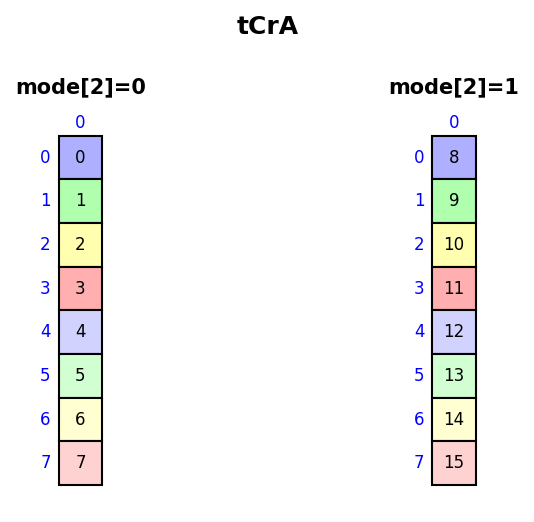

In [18]:
tCsA_stage0 = Layout(((2, 2, 2), 1, 2), ((32, 8, 256), 0, 512))
tCrA = Layout(((2, 2, 2), 1, 2), ((1, 2, 4), 0, 8))
tCsB_stage0 = Layout(((2, 2), 2, 2), ((32, 256), 16, 512))
tCrB = Layout(((2, 2), 2, 2), ((1, 2), 4, 8))

show_layout(
    "tCsA stage 0",
    tCsA_stage0,
    note="Thread-local view of A in SMEM. This is the partition that `ldmatrix`-style loads read from."
)

show_layout(
    "tCrA",
    tCrA,
    note="Register fragment for operand A. This is what the MMA atom actually consumes."
)


### tCsB stage 0

((2, 2), 2, 2) : ((32, 256), 16, 512)


Thread-local SMEM view for operand B before loading into registers.

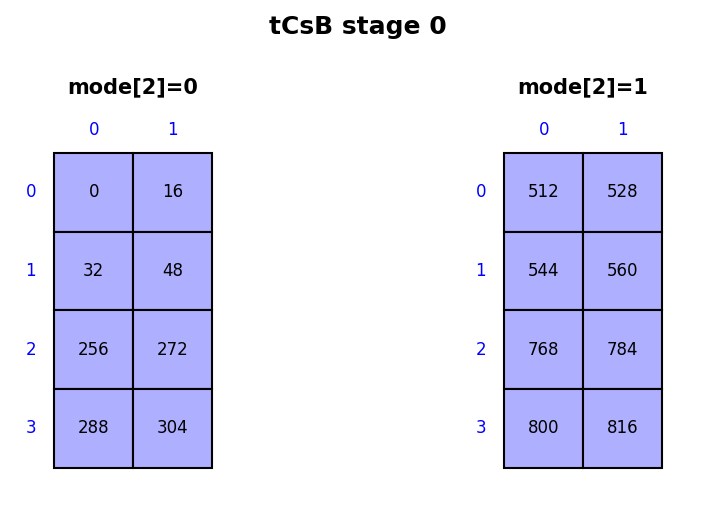

### tCrB

((2, 2), 2, 2) : ((1, 2), 4, 8)


Register fragment for operand B. Together, `tCrA` and `tCrB` feed the warp MMA instruction.

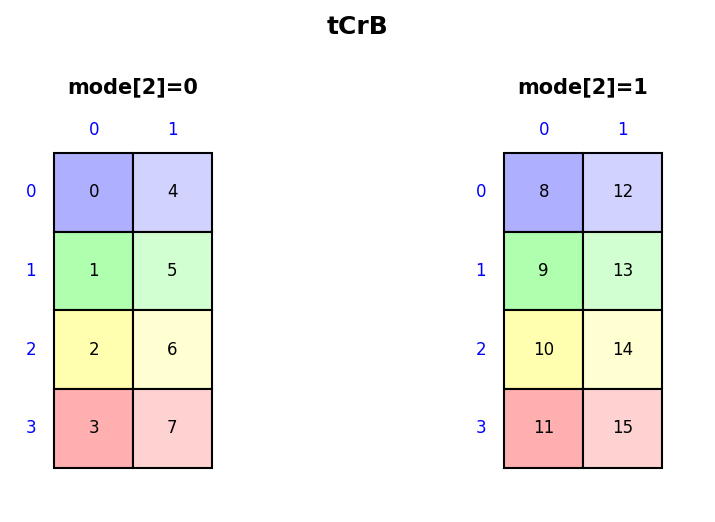

In [19]:
show_layout(
    "tCsB stage 0",
    tCsB_stage0,
    note="Thread-local SMEM view for operand B before loading into registers."
)

show_layout(
    "tCrB",
    tCrB,
    note="Register fragment for operand B. Together, `tCrA` and `tCrB` feed the warp MMA instruction."
)


## 4. Which MMA atom is this kernel using?

In `_setup_attributes()` the SM120 example does:

```python
self.mma_inst_mnk = (16, 8, 16)
op = cute.nvgpu.warp.MmaF16BF16Op(
    self.a_dtype,
    self.acc_dtype,
    self.mma_inst_mnk,
)
```

Then it tiles that atom with:

```python
self.atom_layout = (2, 2, 1)
permutation_mnk = (
    2 * 16,
    2 * 8 * 2,
    1 * 16,
)
```

The code cell below makes that concrete.

A small note about the visualization library: `tensor-layouts` names this warp-level atom using the SM80-style `16x8x16` TN definition, but for this notebook we are using it as a stand-in for the same warp MMA thread/value layout that `sm120/dense_gemm.py` builds with `cute.nvgpu.warp.MmaF16BF16Op(..., (16,8,16))`.

So the executable cell shows both:

- the raw `16x8x16` warp MMA atom
- the tiled MMA used per K block in the kernel, which is `32x32x16`

The full CTA tile is still `32x32x32`, completed by running two K blocks.



Atom: SM80_16x8x16_F32F16F16F32_TN
PTX : mma.sync.aligned.m16n8k16.row.col.f32.f16.f16.f32
shape_mnk: (16, 8, 16)
A atom layout: ((4, 8), (2, 2, 2)) : ((32, 1), (16, 8, 128))
B atom layout: ((4, 8), (2, 2)) : ((16, 1), (8, 64))
C atom layout: ((4, 8), (2, 2)) : ((32, 1), (16, 8))
atom_layout (kernel): (2, 2) : (1, 2)
tiled MMA per K block: (32, 32, 16)


### MMA atom layouts

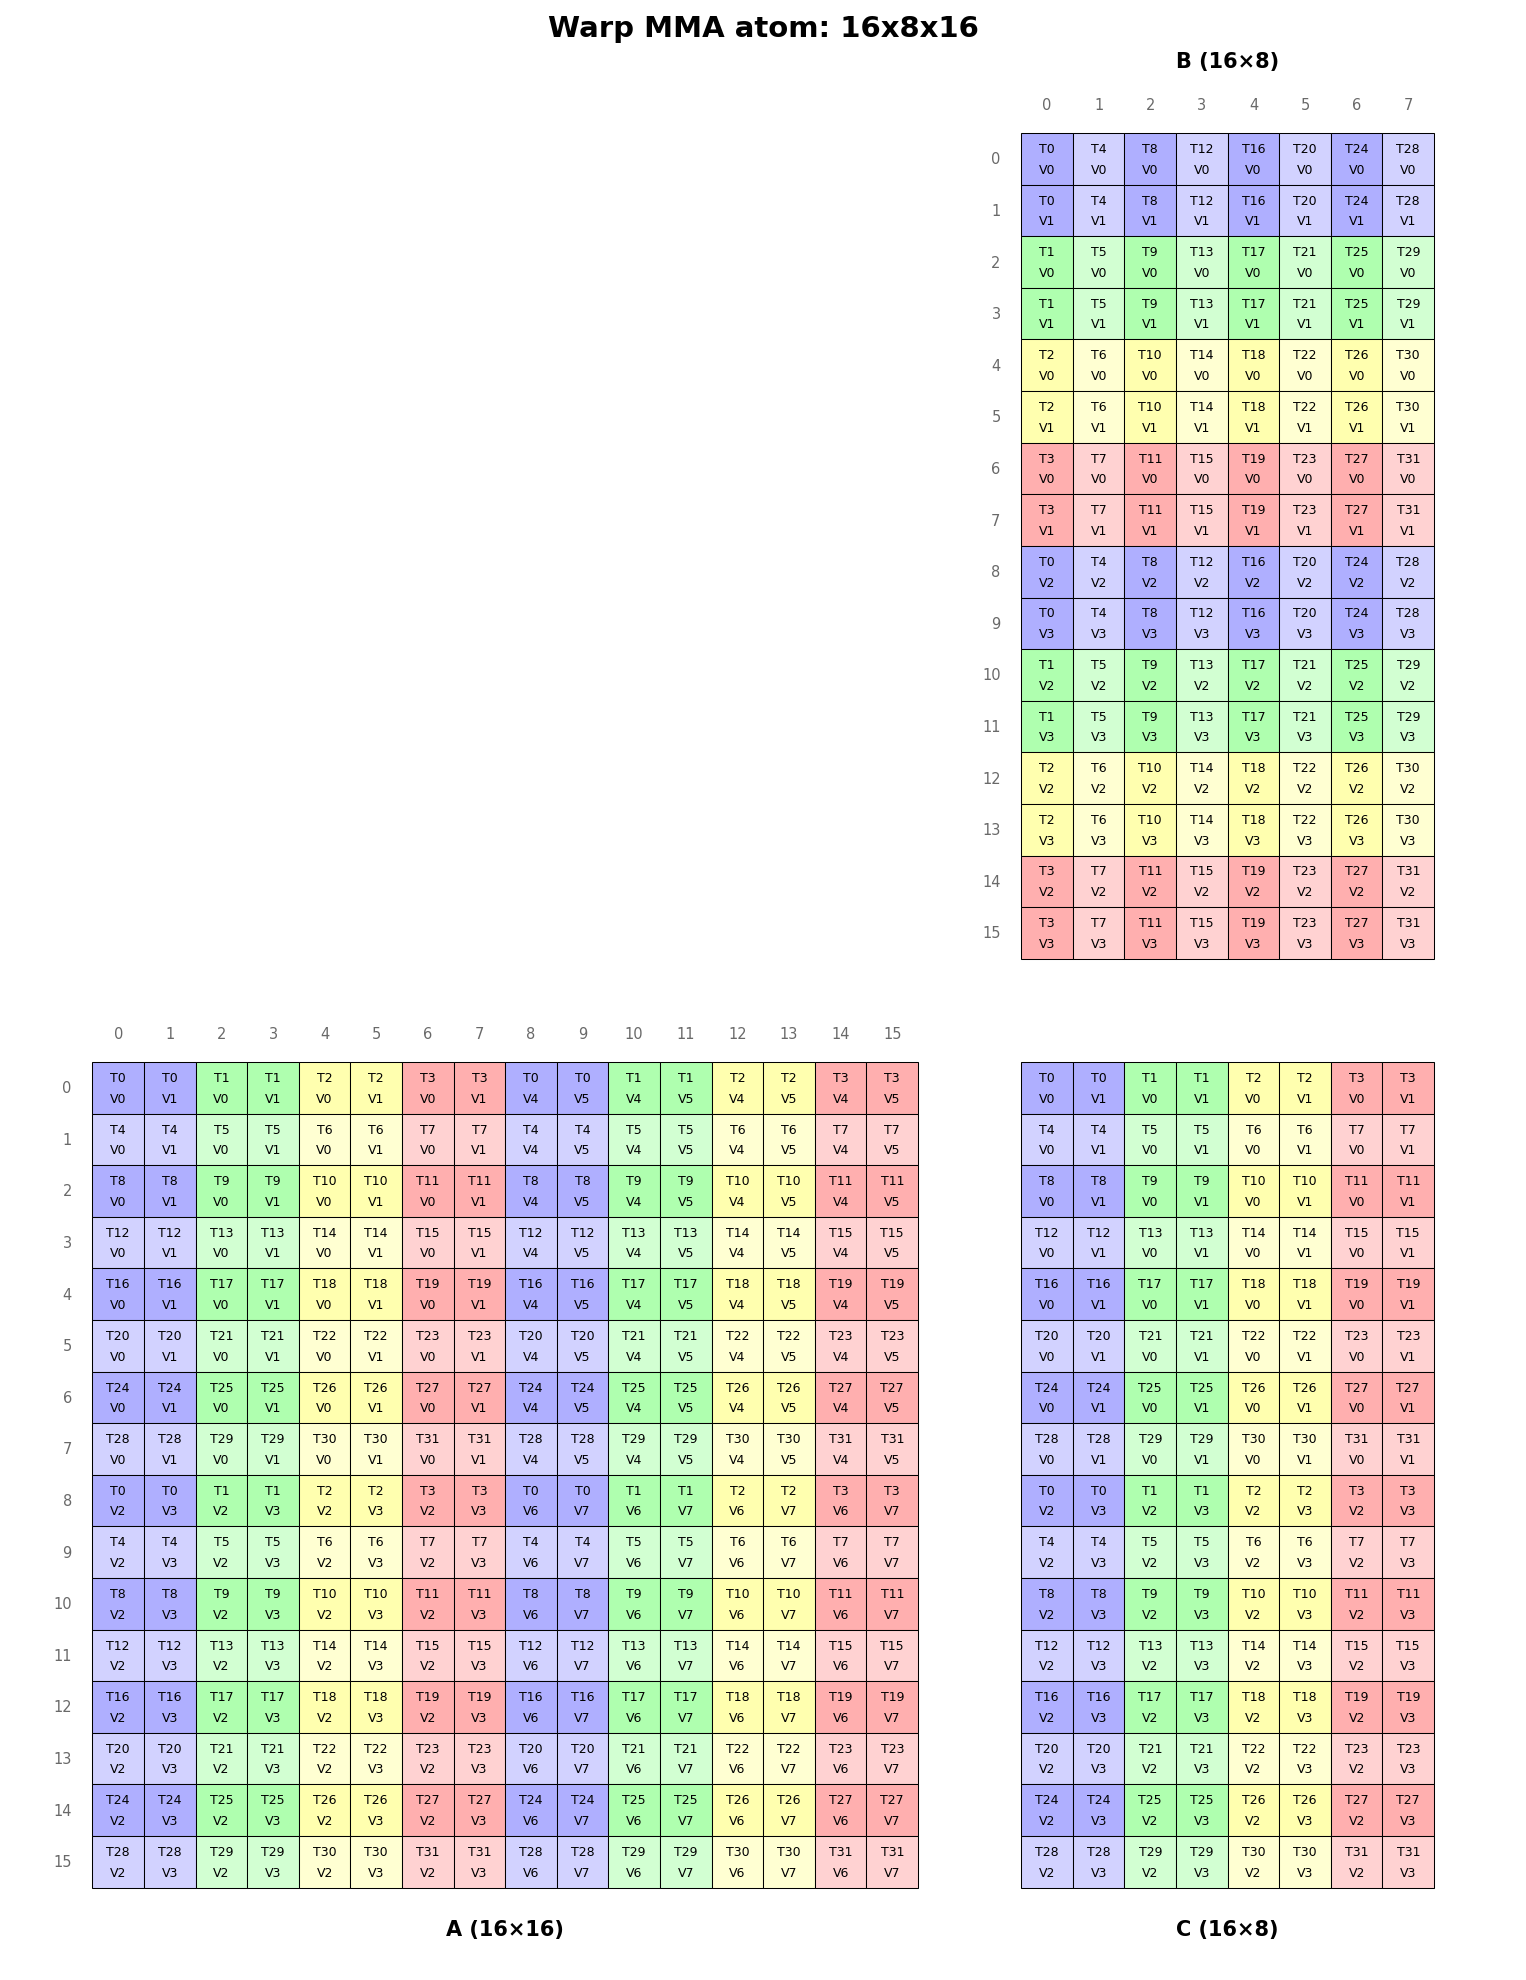

tiled C tile shape: (32, 32, 16)


### Tiled MMA for one K block (`32x32x16`)

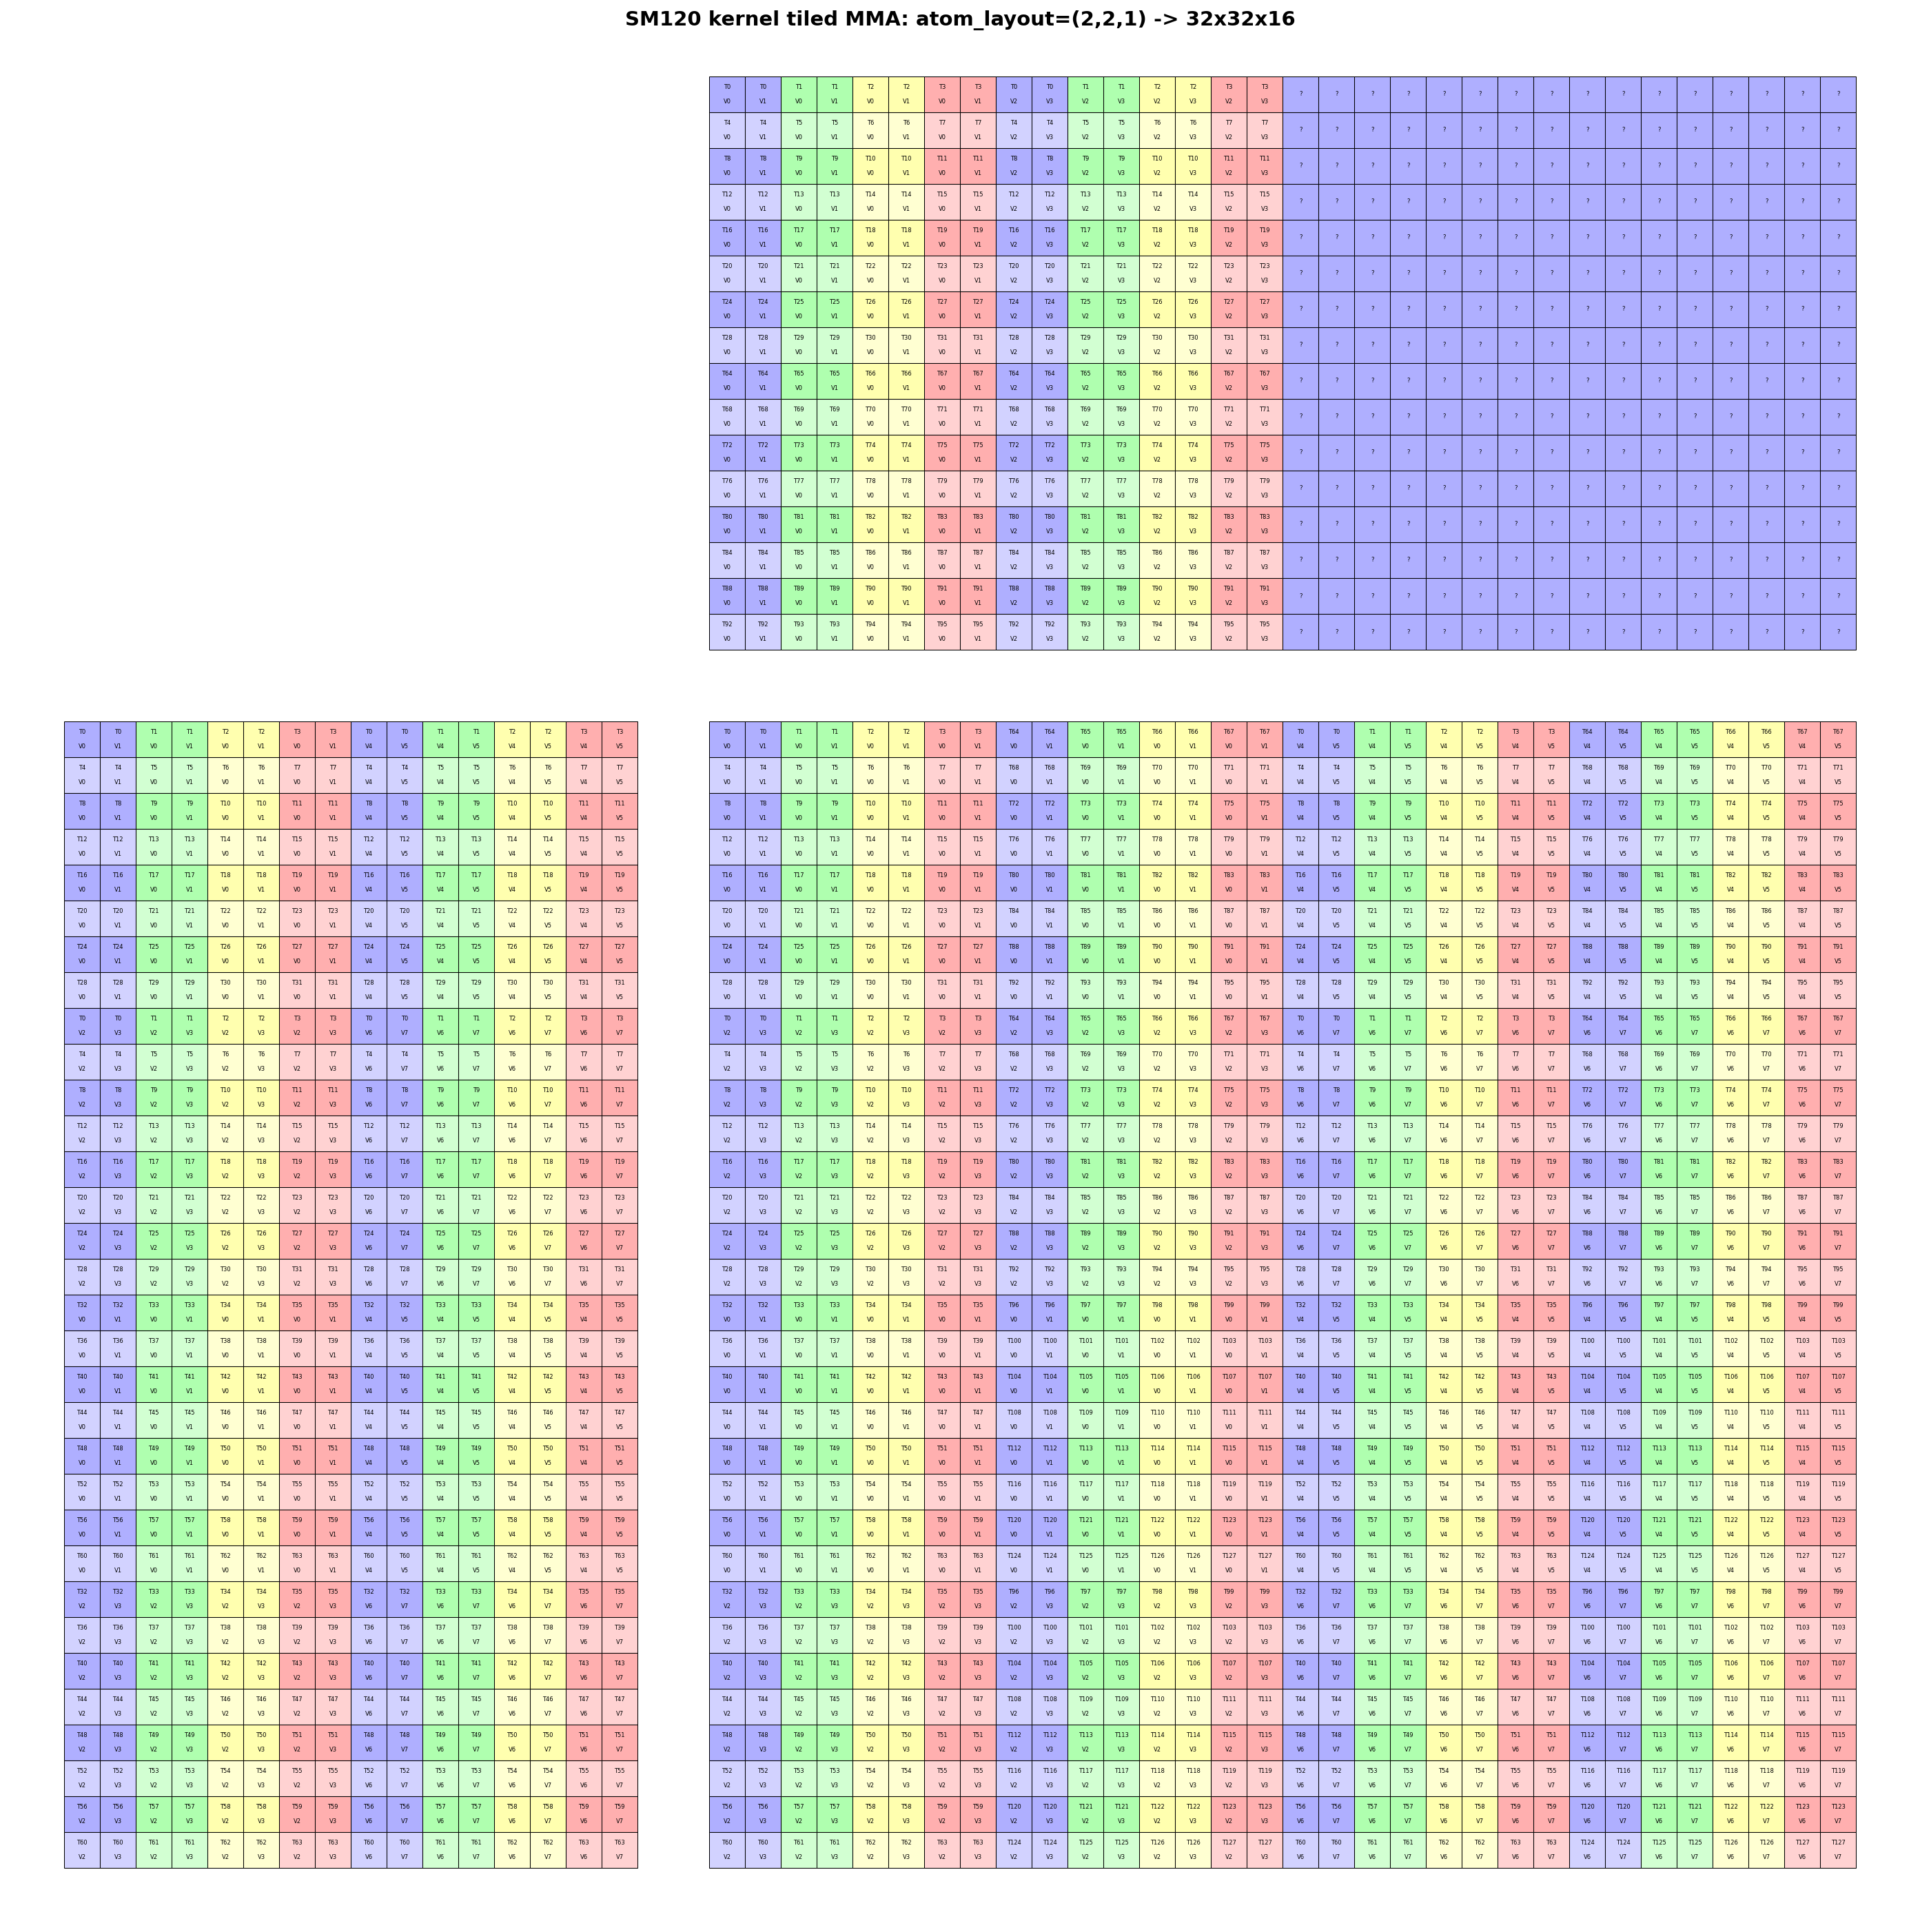

Note: the full CTA tile is 32x32x32, so the kernel runs two of these 32x32x16 K-blocks in sequence.


In [24]:
from tensor_layouts import Layout
from tensor_layouts.atoms_nv import SM80_16x8x16_F32F16F16F32_TN
from tensor_layouts.layout_utils import tile_mma_grid
from tensor_layouts.viz import draw_mma_layout, draw_combined_mma_grid
from IPython.display import Markdown, display

atom = SM80_16x8x16_F32F16F16F32_TN
atom_layout = Layout((2, 2))

print("Atom:", atom.name)
print("PTX :", atom.ptx)
print("shape_mnk:", atom.shape_mnk)
print("A atom layout:", atom.a_layout)
print("B atom layout:", atom.b_layout)
print("C atom layout:", atom.c_layout)
print("atom_layout (kernel):", atom_layout)
print("tiled MMA per K block: (32, 32, 16)")

display(Markdown("### MMA atom layouts"))
draw_mma_layout(
    atom.a_layout,
    atom.b_layout,
    atom.c_layout,
    tile_mnk=atom.shape_mnk,
    main_title="Warp MMA atom: 16x8x16",
)

A_grid, _ = tile_mma_grid(atom, atom_layout, matrix="A", tile_mnk=(32, 32, 16))
B_grid, _ = tile_mma_grid(atom, atom_layout, matrix="B", tile_mnk=(32, 32, 16))
C_grid, tile_shape = tile_mma_grid(atom, atom_layout, matrix="C", tile_mnk=(32, 32, 16))

print("tiled C tile shape:", tile_shape)
display(Markdown("### Tiled MMA for one K block (`32x32x16`)"))
draw_combined_mma_grid(
    A_grid,
    B_grid,
    C_grid,
    M=32,
    N=32,
    K=16,
    title="SM120 kernel tiled MMA: atom_layout=(2,2,1) -> 32x32x16",
)

print("Note: the full CTA tile is 32x32x32, so the kernel runs two of these 32x32x16 K-blocks in sequence.")



## 5. The output side: `tCgC` and the accumulator tensor

The output-side setup is:

```python
tCgC = thr_mma.partition_C(gC_mnl)
acc_shape = tCgC.shape[:3]
accumulators = cute.make_rmem_tensor(acc_shape, self.acc_dtype)
```

Meaning:

- `tCgC` is the per-thread coordinate map for the output tile
- `accumulators` is the actual RMEM tensor that stores the MMA results
- there is no explicit `tCrC`; the kernel allocates the C fragment directly as `accumulators`

The mainloop then does repeated MMA updates:

```python
cute.gemm(
    tiled_mma,
    accumulators,
    tCrA[None, None, k_block_idx],
    tCrB[None, None, k_block_idx],
    accumulators,
)
```

So the value flow is:

- `tCrA`, `tCrB` are the register operands
- `accumulators` is both the destination and the running partial sum
- `tCgC` tells the epilogue where those results belong in `C`


## 6. End-to-end data movement

Here is the kernel’s memory movement in the order it happens:

1. **GMEM logical tensors**
   - `mA_mkl`, `mB_nkl`, `mC_mnl` describe the full matrices.

2. **CTA-local GMEM tiles**
   - `gA_mkl = cute.local_tile(...)`
   - `gB_nkl = cute.local_tile(...)`
   - `gC_mnl = cute.local_tile(...)`

3. **TMA load into staged SMEM**
   - `tAgA` / `tBgB` are the TMA source views in GMEM.
   - `tAsA` / `tBsB` are the TMA destination views in SMEM.
   - the data lands in the staged swizzled buffers `sA` and `sB`.

4. **SMEM to RMEM for MMA**
   - each thread partitions `sA` and `sB` into `tCsA` and `tCsB`
   - `ldmatrix`-style copies move those into register fragments `tCrA` and `tCrB`

5. **MMA in registers**
   - `cute.gemm(...)` accumulates into `accumulators` (Float32 here)

6. **Epilogue RMEM to SMEM**
   - the accumulator fragment is retiled as `tRS_rAcc`
   - the kernel converts to output type via `tRS_rD_out`
   - results are written into `sC`

7. **TMA store back to GMEM**
   - `tma_atom_c` stores from `sC` into the corresponding region of `gC_mnl`
   - logically, those values become the output matrix `mC_mnl`

So the full path is:

```text
A/B in GMEM
  -> gA/gB CTA tiles
  -> TMA
  -> sA/sB staged SMEM buffers
  -> tCsA/tCsB per-thread partitions
  -> tCrA/tCrB register fragments
  -> MMA
  -> accumulators (RMEM)
  -> tRS_rD_out
  -> sC epilogue SMEM buffer
  -> TMA store
  -> C in GMEM
```


In [ ]:
flow = [
    "mA/mB (global tensors)",
    "gA/gB (CTA-local GMEM tiles)",
    "tAgA/tBgB -> TMA load",
    "sA/sB (staged swizzled SMEM)",
    "tCsA/tCsB (per-thread SMEM partitions)",
    "tCrA/tCrB (register MMA operands)",
    "accumulators (register C fragment)",
    "tRS_rD_out (converted epilogue registers)",
    "sC (epilogue SMEM)",
    "TMA store",
    "gC/mC (global output)",
]

for idx, step in enumerate(flow, start=1):
    print(f"{idx:2d}. {step}")
